In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import numpy as np
import pandas as pd
import xarray as xr 
import matplotlib.pyplot as plt

In [81]:
import sys, os
folders = [os.path.abspath("../modules/"), 
           os.path.abspath("../dataset/"),
           os.path.abspath("../benchmarking/")
        ]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from helpers import get_simulator
from cost import DesignSpaceHierarchyCost, MarginalCost
from AFL.double_agent.Pipeline import Pipeline 
from AFL.double_agent.Generator import CartesianGrid 
from AFL.double_agent.Preprocessor import Standardize 


In [82]:
sim = get_simulator("../dataset/")
ds_list = []
protein_init = np.random.uniform(low=0.0, high=80.0)
glycerol_init = np.random.uniform(low=0.0, high=12.0)
for temp in [0,10,20,30,40,50]:
    ds = sim.simple_expose({'protein':protein_init,'temperature':temp,'glycerol':glycerol_init})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['batch_sample_id'] = 2
    ds_list.append(ds)

ds_running = xr.concat(ds_list, dim='sample')

In [83]:
ds_running

<xarray.Dataset> Size: 43kB
Dimensions:          (sample: 6, q: 281, ds_dim: 3)
Coordinates:
  * q                (q) float64 2kB 0.003836 0.004348 ... 0.6293 0.6334
  * ds_dim           (ds_dim) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I                (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless      (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI               (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    design_space     (sample, ds_dim) float64 144B 18.53 0.0 ... 50.0 5.349
    phases           (sample) int64 48B 2 1 1 1 0 0
    batch_sample_id  (sample) int64 48B 2 2 2 2 2 2
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [84]:
with Pipeline(name = "setup") as setup:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize-Grid",
    )

setup.print()
ds_result = setup.calculate(ds_running, disable_progress_bar=True)
ds_result

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize-Grid>                  design_space_grid ---> normalized_design_space_grid

Input Variables
---------------
0) CartesianGridGenerator
1) design_space

Output Variables
----------------
0) normalized_design_space
1) normalized_design_space_grid


<xarray.Dataset> Size: 427kB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
Dimensions without coordinates: sample, ds_grid
Data variables:
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) float64 144B 18.53 ... 5.349
    phases                        (sample) int64 48B 2 1 1 1 0 0
    batch_sample_id               (sample) int64 48B 2 2 2 2 2 2
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    normalized_design_space       (sample, ds_dim) float64 144B 0.2316 ... 0....
    normalized_design_space_grid  (ds_grid, ds_dim) float64 192kB 0.0 ... 1.0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [85]:
DSHC = DesignSpaceHierarchyCost(
        input_variable = "normalized_design_space_grid",
        iteration_variable = "batch_sample_id",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        component_dim = "ds_dim",
        coordinates_order = ['temperature', 'protein', 'glycerol'], # from highest to lowest cost
        coordinates_offsets = [0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name = "DesignSpaceHierarchyCost",        
    )
out_dshc = DSHC.calculate(ds_result)
ds_result = DSHC.add_to_dataset(ds_result)
out_dshc.output

{'hierarchy_cost': <xarray.DataArray (ds_grid: 8000)> Size: 64kB
 array([0.09130453, 0.06348798, 0.07520269, ..., 0.18790747, 0.2294039 ,
        0.2183512 ], shape=(8000,))
 Dimensions without coordinates: ds_grid
 Attributes:
     description:         Cost per sample evaluated on normalized_design_space...
     name:                DesignSpaceHierarchyCost
     input_variable:      ['normalized_design_space_grid']
     output_variable:     hierarchy_cost
     input_prefix:        None
     output_prefix:       None
     _stored_args:        {'input_variable': 'normalized_design_space_grid', '...
     iteration_vairable:  batch_sample_id}

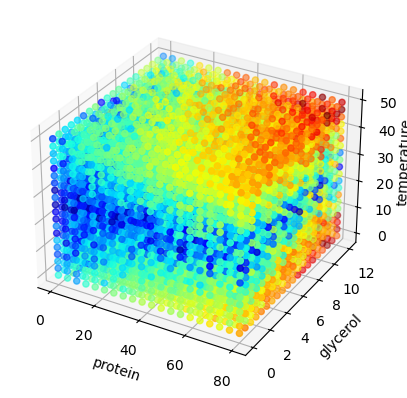

In [86]:
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
X = ds_result['design_space_grid'].values
y = out_dshc.output['hierarchy_cost'].values
ax.scatter(X[:,0], X[:,2], X[:,1], c=y, cmap="jet")
ax.set_xlabel(ds_result.components[0])
ax.set_ylabel(ds_result.components[2])
ax.set_zlabel(ds_result.components[1], labelpad=-1)
plt.show()


In [87]:
MC = MarginalCost(
        input_variable = "hierarchy_cost",
        coordinate_dims = ['temperature'],
        component_dim = "ds_dim",
        grid_variable = "design_space_grid",
        output_variable="composition_hierarchy_cost",
        name= "MarginalCost",
    )
out_mc = MC.calculate(ds_result)
ds_result = MC.add_to_dataset(ds_result)
ds_result

<xarray.Dataset> Size: 501kB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000,
                                   protein_glycerol_n: 400,
                                   protein_glycerol_d: 2)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
  * protein_glycerol_d            (protein_glycerol_d) <U8 64B 'protein' 'gly...
Dimensions without coordinates: sample, ds_grid, protein_glycerol_n
Data variables:
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) float64 144B 18.53 ... 5.349
    phases                        (sample) int64 48B 2 1 1 1 0 0
    batch_sample_id               (sample) int64 48B 2 2 2 2 2 2
    design_space_grid             (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    normalized_design_space       (sample, ds_dim) float64 144B 0.2316 ... 0....
    normalized_design_space_grid  (ds_grid, ds_dim) float64 192kB 0.0 ... 1.0
    hierarchy_cost                (ds_grid) float64 64kB 0.0913 ... 0.2184
    composition_hierarchy_cost    (protein_glycerol_n) float64 3kB 0.05345 .....
    protein_glycerol_domain       (protein_glycerol_n, protein_glycerol_d) float64 6kB ...
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

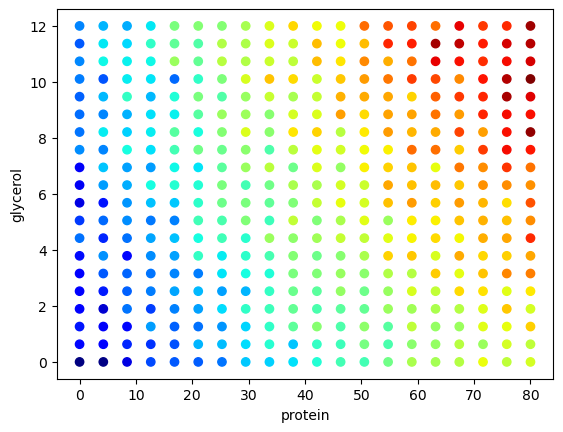

In [88]:
fig, ax = plt.subplots()
ax.scatter(
    ds_result.protein_glycerol_domain[:,0],
    ds_result.protein_glycerol_domain[:,1],
    c = ds_result['composition_hierarchy_cost'],
    cmap = "jet"
)
ax.set_xlabel(ds_result.components[0])
ax.set_ylabel(ds_result.components[2])
plt.show()